Reconstruction is decent and Basis Actually make sense for. 

In [ ]:
import sys
sys.path.append("..")
import numpy as np, torch
import scipy.stats as st
import itertools
from decompTCR.tools._basis_decomposition.run_batch import compute_basis_decomposition, _plot_basis, get_basis
from decompTCR.tools._basis_decomposition.inference  import InferenceMode
from pyro.infer import Predictive, TraceEnum_ELBO
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
import pandas as pd
import pickle
import os
from sklearn.preprocessing import MaxAbsScaler, StandardScaler, MinMaxScaler
import datetime
from sklearn.preprocessing import LabelEncoder
from umap import UMAP

import pyro

from sklearn.neighbors import kneighbors_graph
from sknetwork.clustering import Louvain
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from umap import UMAP
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde


from decompTCR.tools._basis_decomposition.inference import get_inference_guide
from decompTCR.tools._basis_decomposition.model_batch import BasisDecomposition, BasisDecomposition_Evaluate
from pyro.infer import Predictive, SVI, Trace_ELBO, TraceTMC_ELBO

from utils import display_cat, clear_val_params, summary, process_data, find_sequence_rows_regex, clustermap, bernoulli_downsample





## Generate Toy Data

In [2]:
#This is purely for figure clonerating the
sin_f = np.sin(np.linspace(0, 6.28, 181)*2)+1
inc_f = 1*np.linspace(0,1,181)
dec_f = -1*np.linspace(0,1,181)+1
sigp_f = 1/(1 + np.exp(-np.linspace(-10,20,181))) 
sign_f = -1/(1 + np.exp(-np.linspace(-5,20,181))) + 1 

sin_f = (sin_f - np.min(sin_f))/np.max(sin_f)
sigp_f = (sigp_f - np.min(sigp_f))/np.max(sigp_f) 
sign_f = (sign_f - np.min(sign_f))/np.max(sign_f)

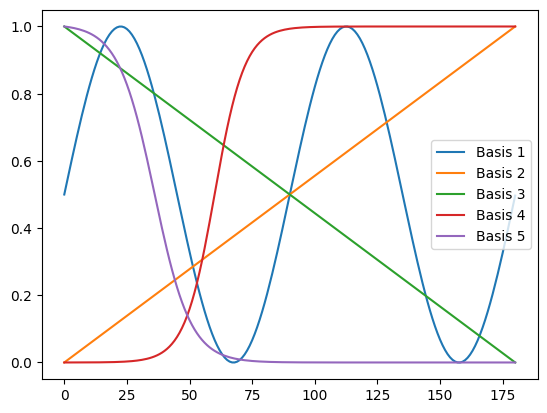

In [3]:
#Plotting the chosen basis
plt.plot(sin_f)
plt.plot(inc_f)
plt.plot(dec_f)
plt.plot(sigp_f)
plt.plot(sign_f)
plt.legend(["Basis 1", "Basis 2", "Basis 3", "Basis 4", "Basis 5"])

In [4]:
#Sample the weights for each basis randomly from a dirichlet distribution and clonerate new functions
random_weights = np.random.dirichlet((0.5, 0.5, 0.5, 0.5, 0.5), 10000)
new_functions = [random_weights[i,0]*sin_f + random_weights[i,1]*inc_f + random_weights[i,2]*dec_f + random_weights[i,3]*sigp_f + random_weights[i,4]*sign_f for i in range(len(random_weights[:,0]))] 
new_functions = np.array(new_functions)

#Now we downsample the functions to make it similar to real data. We use a bernoulli downsampling scheme where as time goes on, the probability of observing a point decreases from 5% to .1%.
new_functions_ds = bernoulli_downsample(new_functions, 0.05, 0.001)

The data is n by t (n clones, t timepoints)

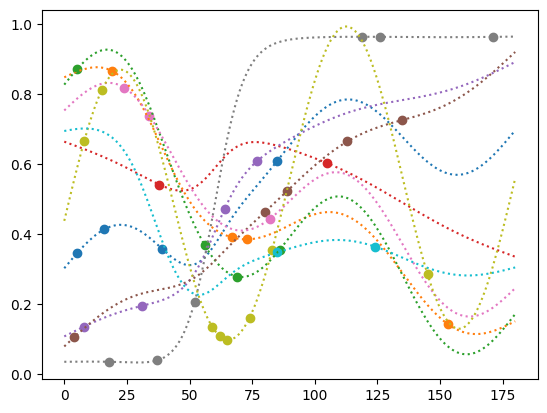

In [5]:
times = np.arange(0,181,1)
for i in range(10):
    plt.scatter(times,new_functions_ds[i,:])
    plt.plot(times, new_functions[i,:], linestyle = ":")

Lets visualize the true weights of our new functions.

/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/anaconda3/envs/pyro/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


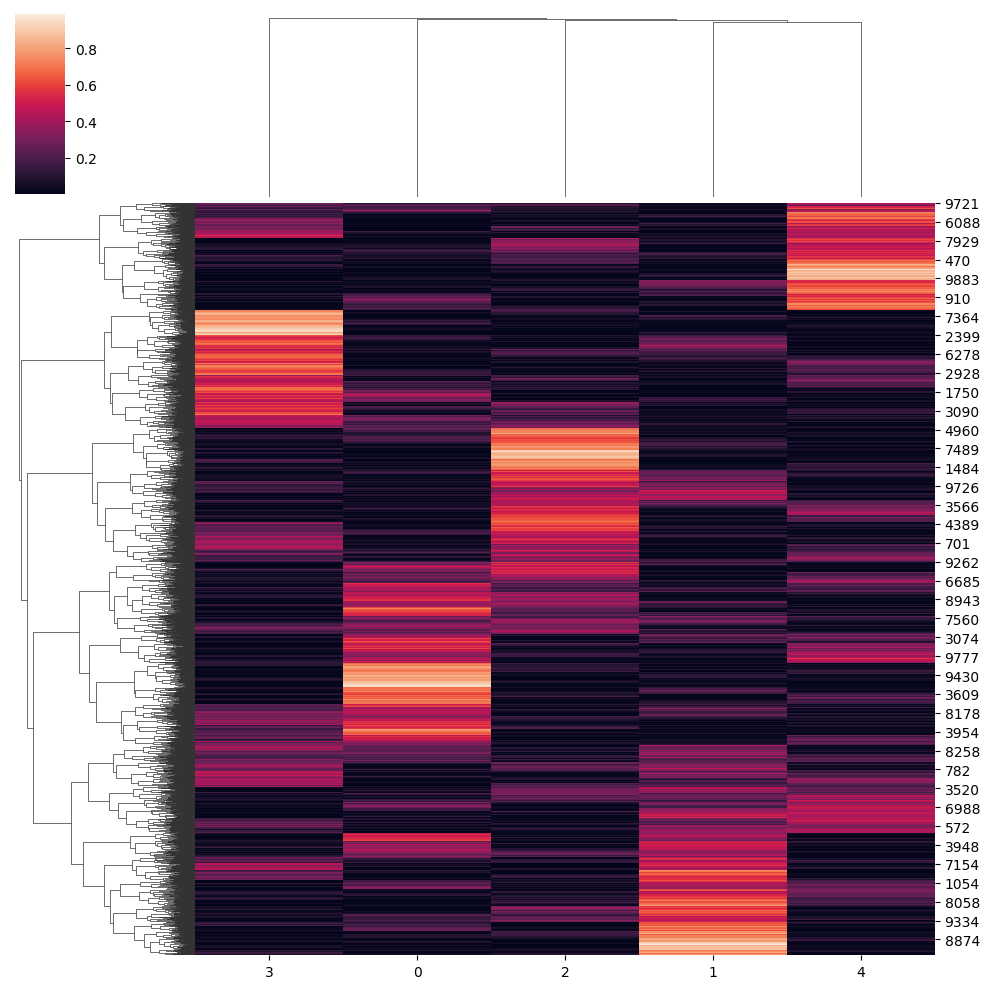

In [6]:
sns.clustermap(random_weights)

## Preprocessing

Ensure your data array is n clones by n timepoints, where missing values are represented as np.nan values.

In [7]:
new_functions_ds = torch.FloatTensor(new_functions_ds)

train_a_idx, val_a_idx = train_test_split(np.arange(new_functions_ds.shape[0]), test_size = 0.1)
clone_patterns_padded_allo_train = new_functions_ds[train_a_idx,:]
clone_patterns_padded_allo_val = new_functions_ds[val_a_idx,:]

gt = torch.FloatTensor(new_functions)
gt_train = gt[train_a_idx,:]
gt_val = gt[val_a_idx,:]

## Fit the Model

In [ ]:
n_basis = 5
n_iter = 2_000
show_basis = False
lr = 1e-2
beta_prior = 0.001 #Low beta prior to encourage sparsity
weight_decay = 1e-7
inverse_length_scale = 6 #Higher value = more complex basis functions
times_padded = np.linspace(-1,1,181)

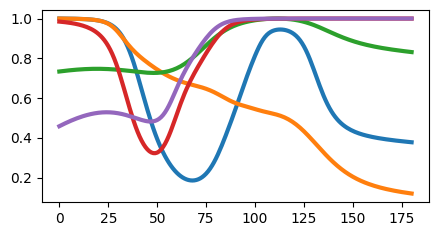

Loss: 154204.6 - Relative Error: 0.05, - Val_loss: 0.05: 100%|██████████| 2000/2000 [04:46<00:00,  6.98it/s]


In [ ]:

trajectory_model_a, guide_a, times_a, samples_a, clone_scales_a, losses_a, rel_loss_a, val_loss_a = compute_basis_decomposition(
clone_patterns_padded_allo_train.numpy(),
InferenceMode.GAUSSIAN_BETA_ONLY, 
n_basis=n_basis,
n_iter=n_iter,
batch_size=None,
#show_basis=show_basis,
lr=lr,
beta_prior=beta_prior,
weight_decay = weight_decay,
inverse_length_scale = inverse_length_scale,
seed=1,
normalized_mode=True,
times = np.linspace(-1,1,181),
plot_every_k_epochs=100,
clone_patterns_val= clone_patterns_padded_allo_val.numpy()
) 



## Displaying Results

In [10]:
clone_patterns_mean = clone_patterns_padded_allo_train.nanmean(axis = -1, keepdim= True)

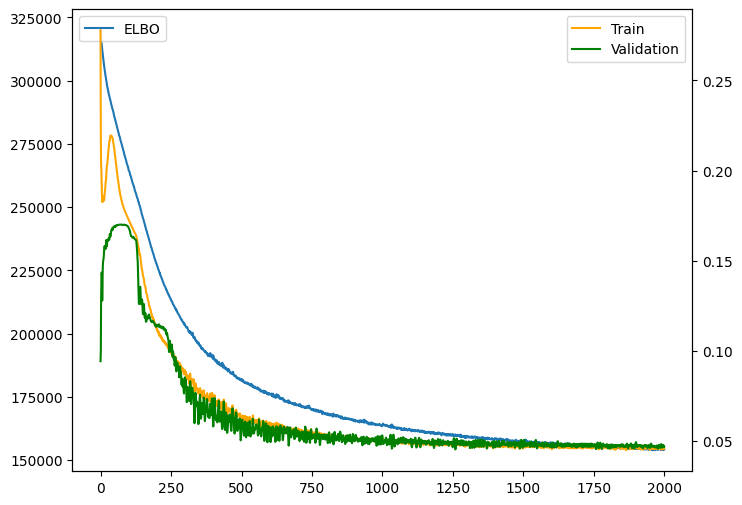

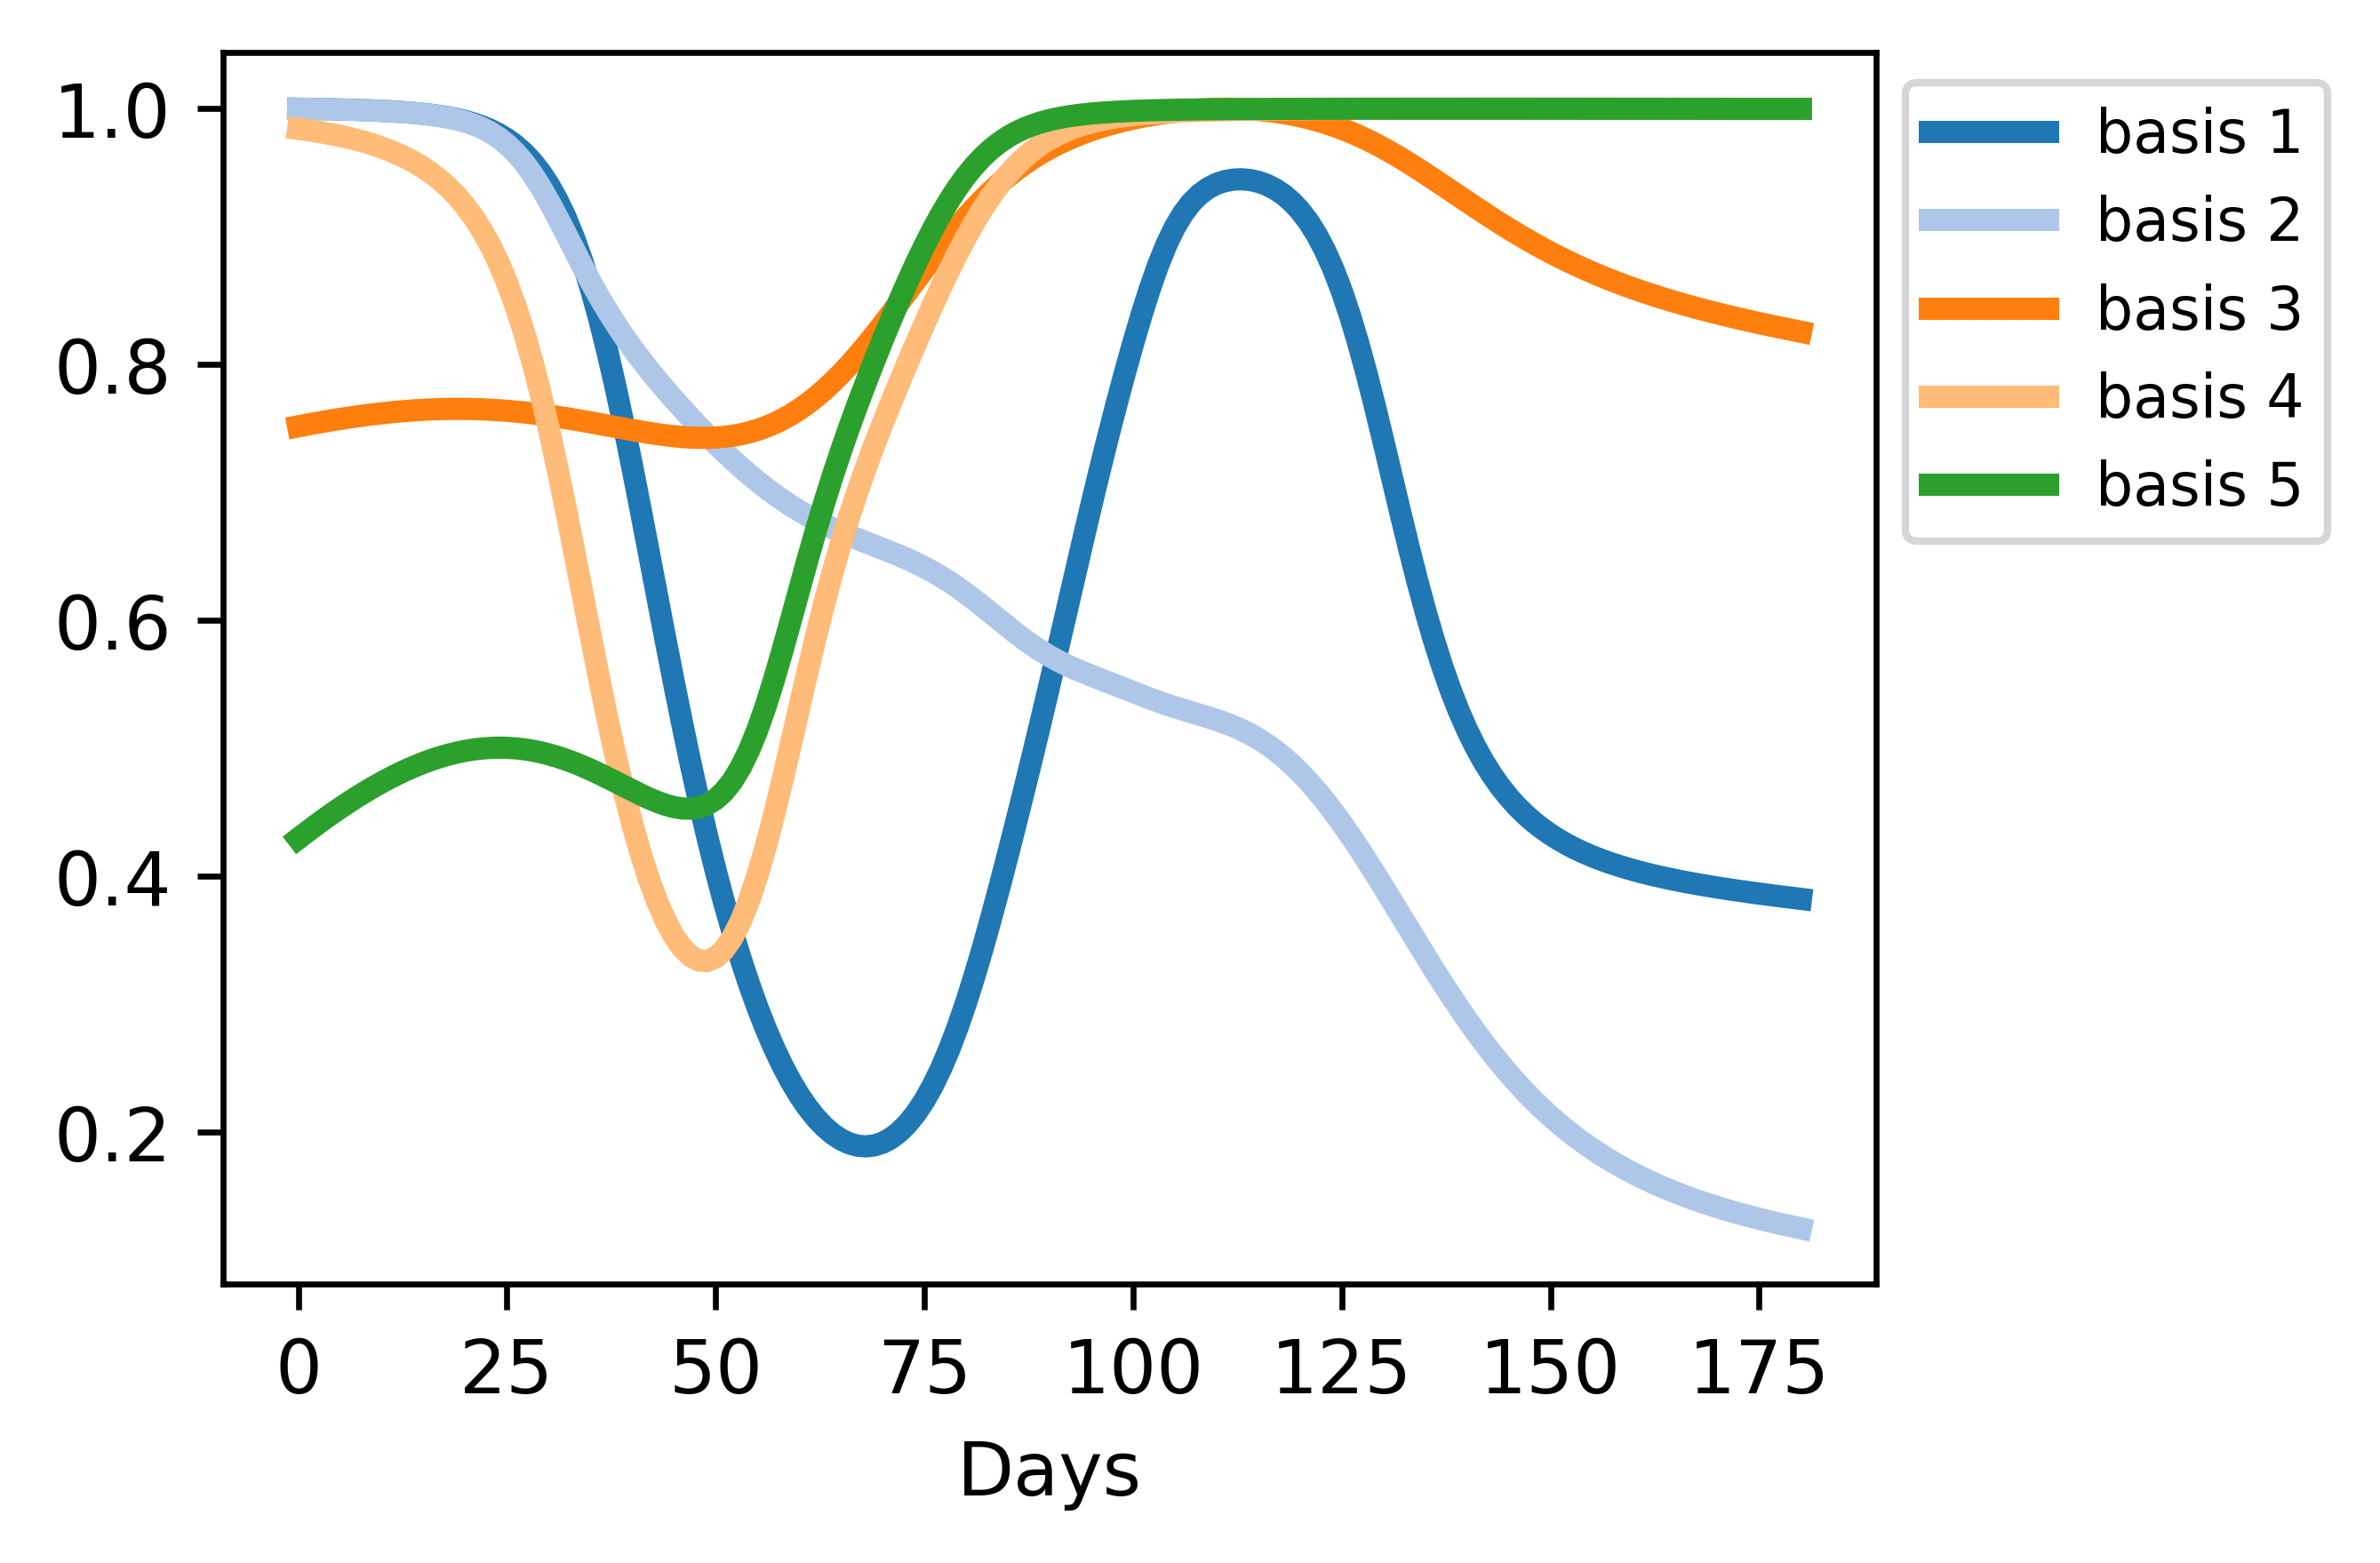

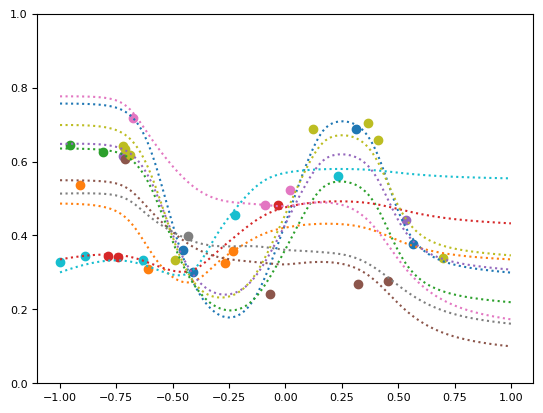

In [11]:

fig, ax = plt.subplots(1,1, figsize = (8,6))
ax.plot(losses_a)
ax2 = ax.twinx()
ax2.plot(rel_loss_a, color = "orange")
ax2.plot(val_loss_a, color = "green")
ax.legend(["ELBO"], loc = "upper left")
ax2.legend(["Train", "Validation"])

plt.savefig("../FigureOutput/generated_Output/Figure2/SignifBasisWeightViolinPlot.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/SignifBasisWeightViolinPlot.pdf", dpi = 600, bbox_inches='tight')

plt.show()

basis_a = get_basis(trajectory_model_a, guide_a, clone_patterns_padded_allo_train.numpy(), times_a)
# torch.save(basis_a, "../input_data/basis_decomp_generated_saved_runs/"+formatted_datetime+"basis_a.pth")
# basis_a = torch.load("../input_data/basis_decomp_generated_saved_runs/_2024_04_29_10_34_01basis_a.pth")

colors = sns.color_palette("tab20", 20)

#basis = get_basis(trajectory_model, guide, clone_patterns, times)
fig, ax = plt.subplots(1,1, figsize=(4,3), dpi = 600)
plt.rcParams.update({'font.size': 8})
ax = _plot_basis(basis_a, colors)
plt.xlabel("Days")
plt.legend(bbox_to_anchor=(1,1),loc = "upper left")

plt.savefig("../FigureOutput/generated_Output/Figure2/SignifBasisWeightViolinPlot.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/SignifBasisWeightViolinPlot.pdf", dpi = 600, bbox_inches='tight')

plt.show()



reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

m = 10
palette = sns.color_palette(n_colors=m)
for i in range(m):
    idx = np.random.randint(0,len(clone_patterns_padded_allo_train))
    plt.scatter(times_padded, clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette[i])
    # plt.plot(times, new_functions_ds[0,idx].detach().numpy(), color = palette[i])
    plt.plot(times_padded, reconstruction.numpy()[idx,:], ls = ':', color = palette[i])
plt.ylim([0,1])

plt.savefig("../FigureOutput/generated_Output/Figure2/SignifBasisWeightViolinPlot.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/SignifBasisWeightViolinPlot.pdf", dpi = 600, bbox_inches='tight')

plt.show()



We fix the model parameters and fit our validation data.

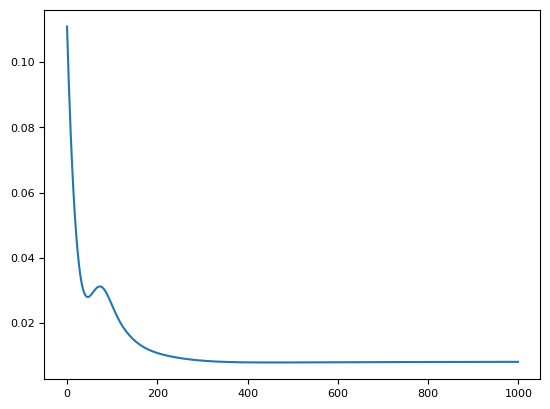

In [12]:
clear_val_params()

adam = pyro.optim.ClippedAdam({"lr": .01})
elbo = Trace_ELBO()
    
model_val = BasisDecomposition_Evaluate(
            trajectory_model_a._last_basis.detach(),
            clone_patterns_padded_allo_val.shape[0],
            beta_prior=beta_prior,
            normalized_mode = True
            
        )
guide_val = get_inference_guide(model_val, InferenceMode.POINT_ESTIMATE)
svi_val = SVI(model_val, guide_val, adam, loss=elbo)
val_loss = []
loss_val = 0
for _ in range(1000):
    loss_val = svi_val.step(torch.FloatTensor(times_padded), torch.FloatTensor(clone_patterns_padded_allo_val.numpy()))
    reconstruction_val = ((model_val._last_patterns - clone_patterns_padded_allo_val) ** 2).nanmean().item()
    val_loss.append(reconstruction_val)


plt.plot(val_loss)


samples = []
predictive = Predictive(
        model_val, guide=guide_val, num_samples=10, return_sites=("beta_val","_RETURN",  "obs_val")
    )
samples = predictive(times_a, clone_patterns_padded_allo_val)#, None)

clone_scales = model_val.gene_scales
samples = summary(samples)


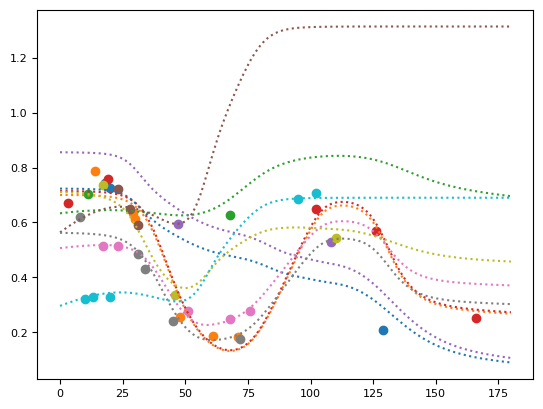

In [13]:
reconstruction_val = samples["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()

m = 10
palette = sns.color_palette(n_colors=m)
for i in range(m):
    idx = np.random.randint(0,len(clone_patterns_padded_allo_val))
    plt.scatter(np.arange(0,181), clone_patterns_padded_allo_val[idx,:].detach().numpy(), color = palette[i])
    # plt.plot(times, clone_patterns[0,idx,:].detach().numpy(), color = palette[i])
    plt.plot(np.arange(0,181), reconstruction_val.numpy()[idx,:], ls = ':', color = palette[i])
plt.show()

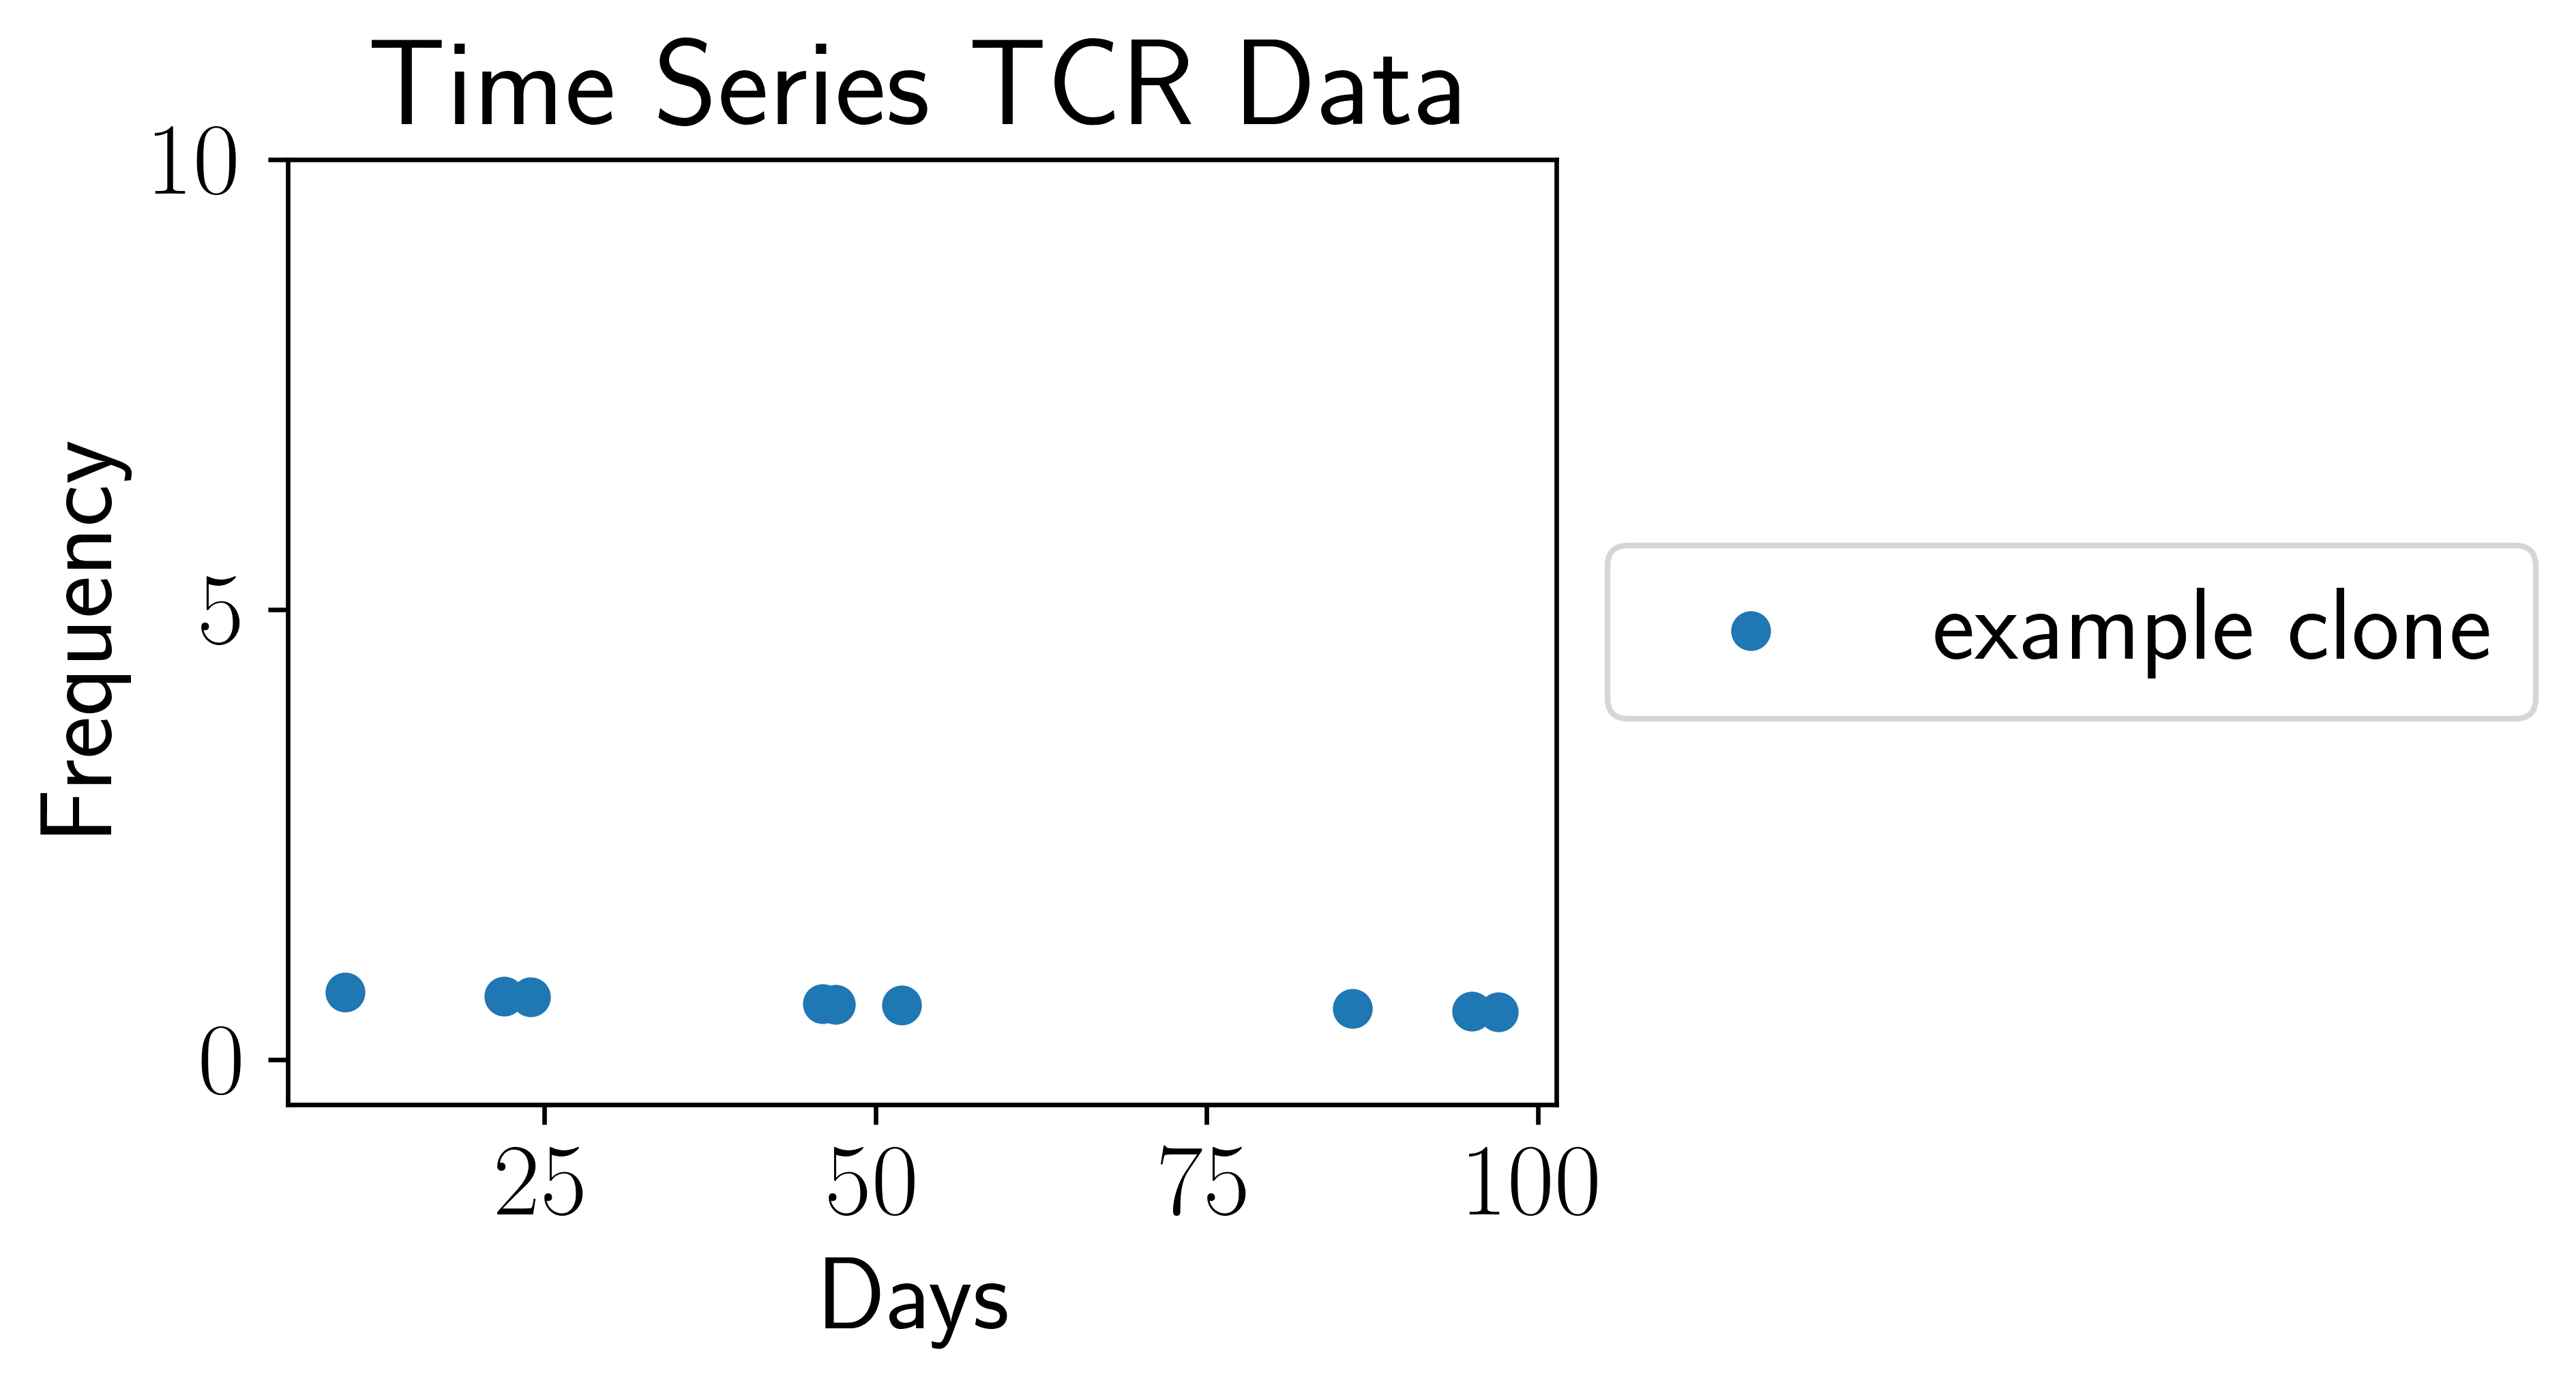

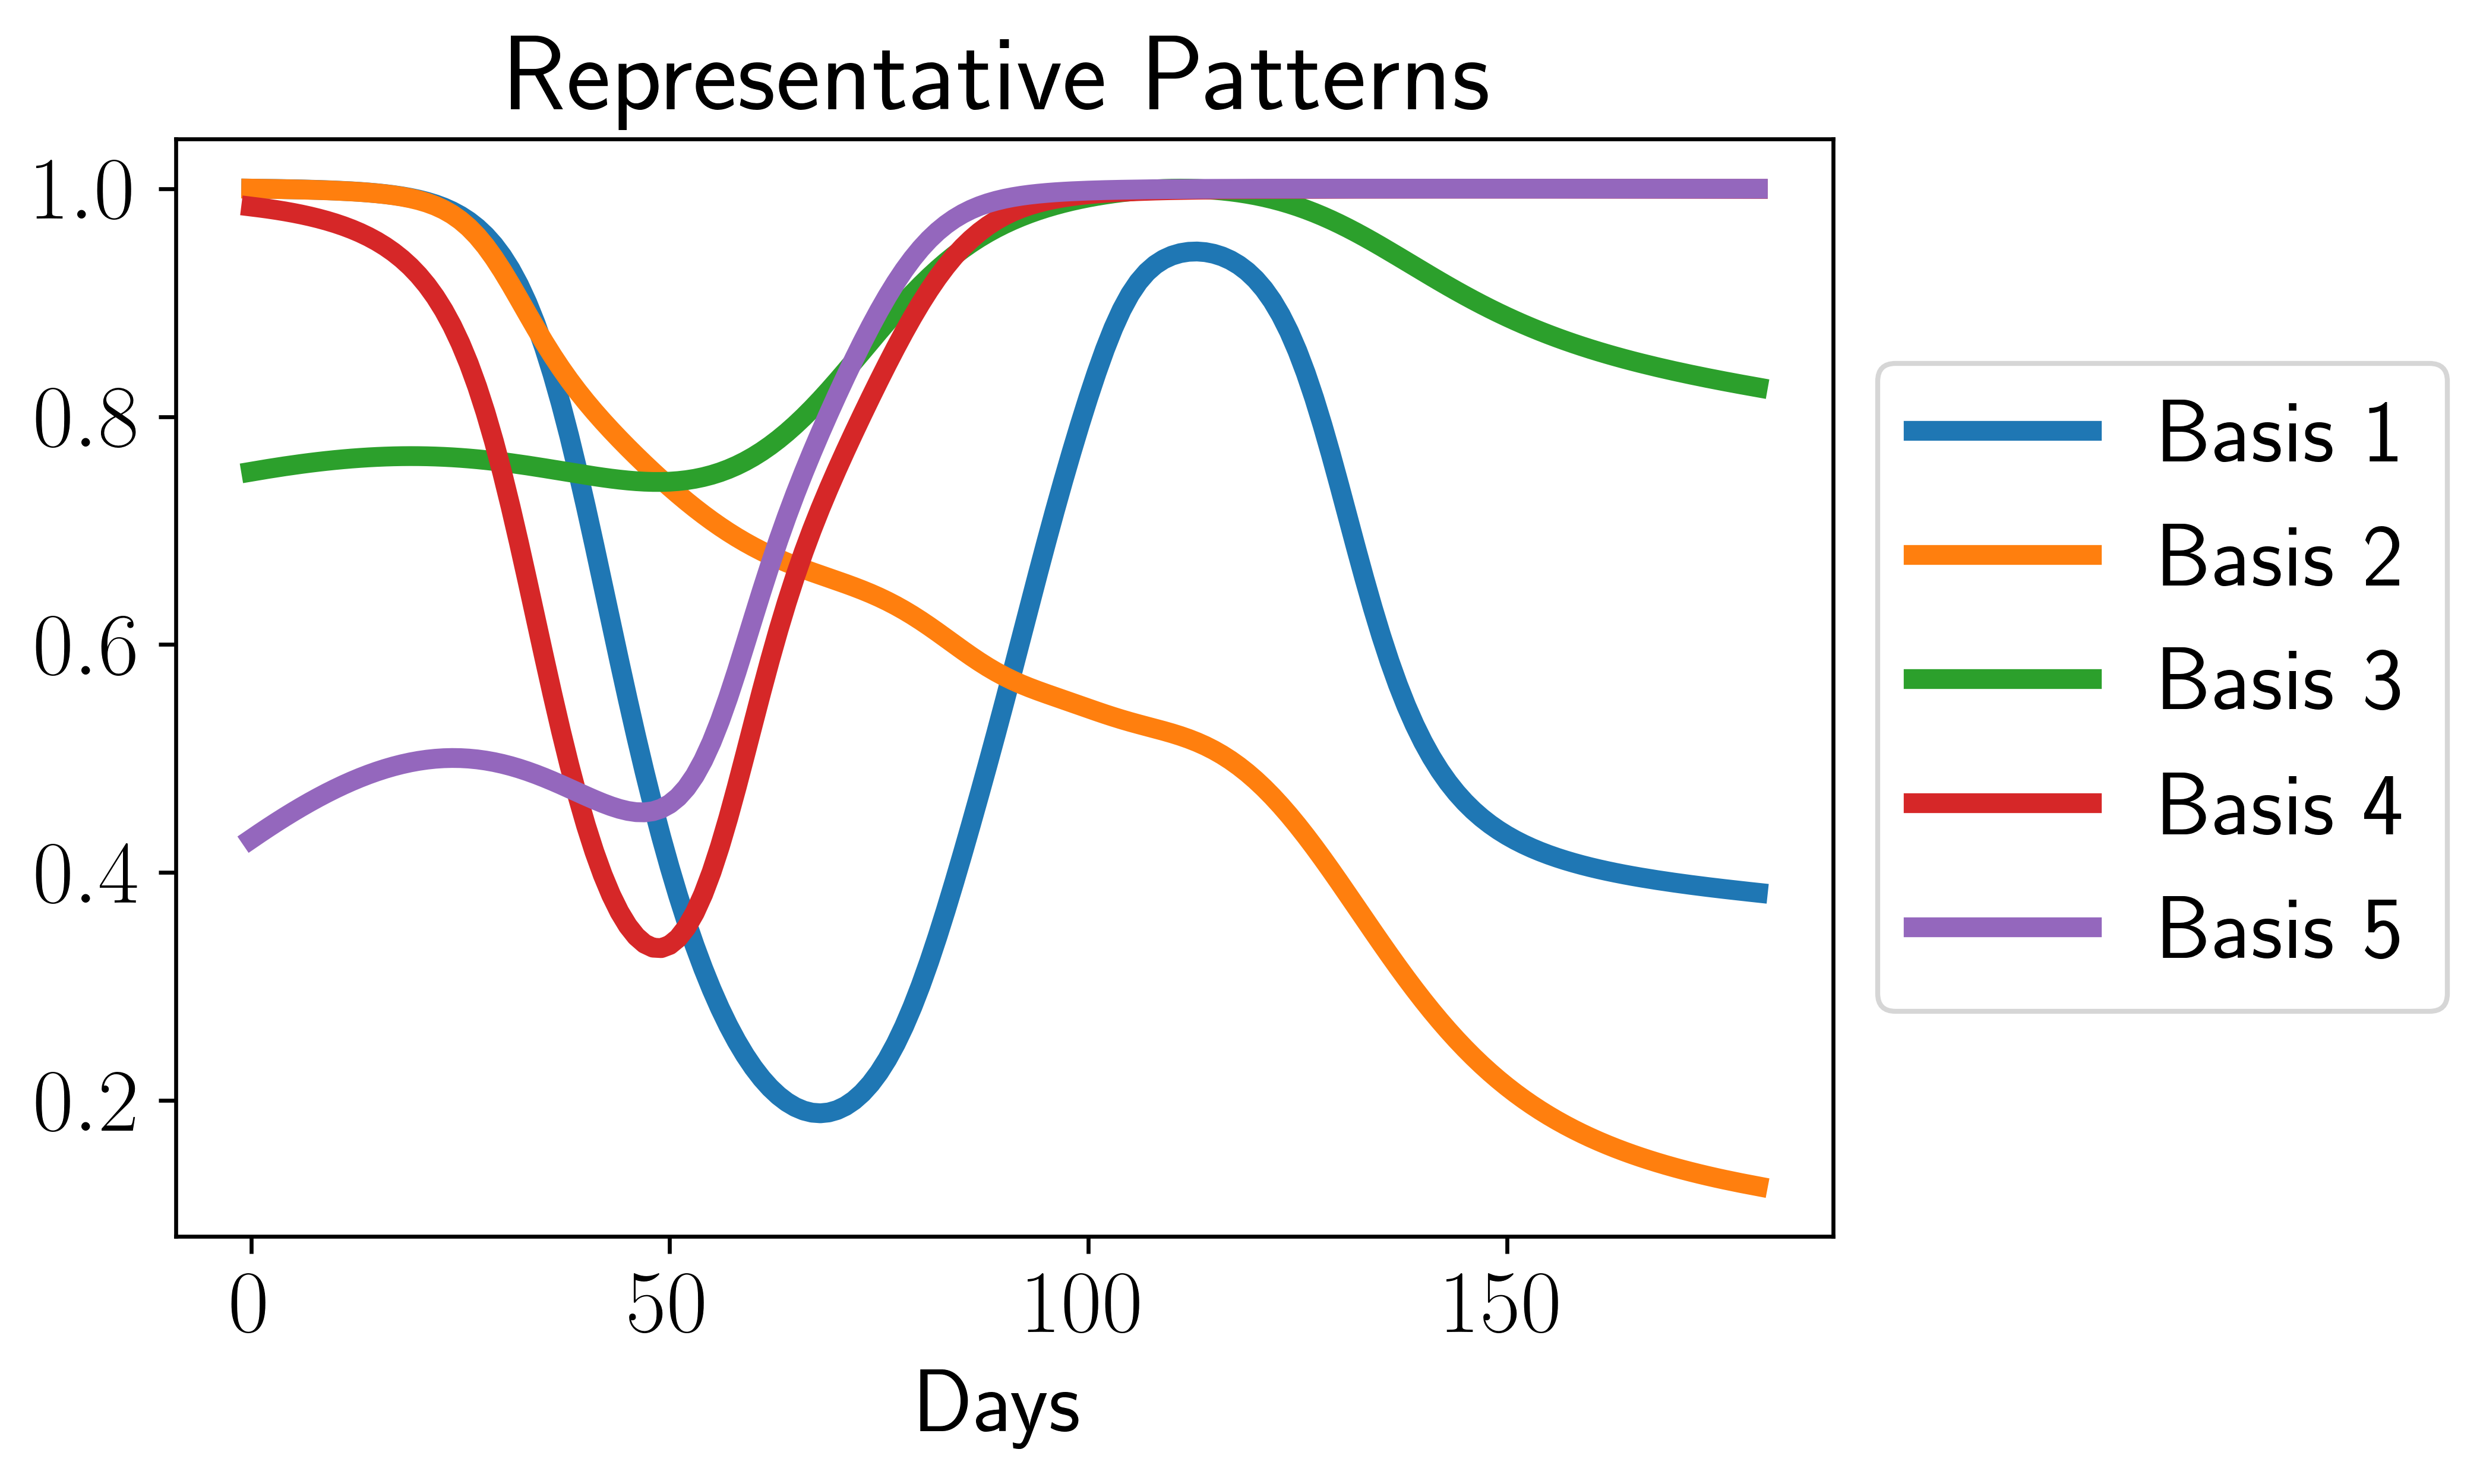

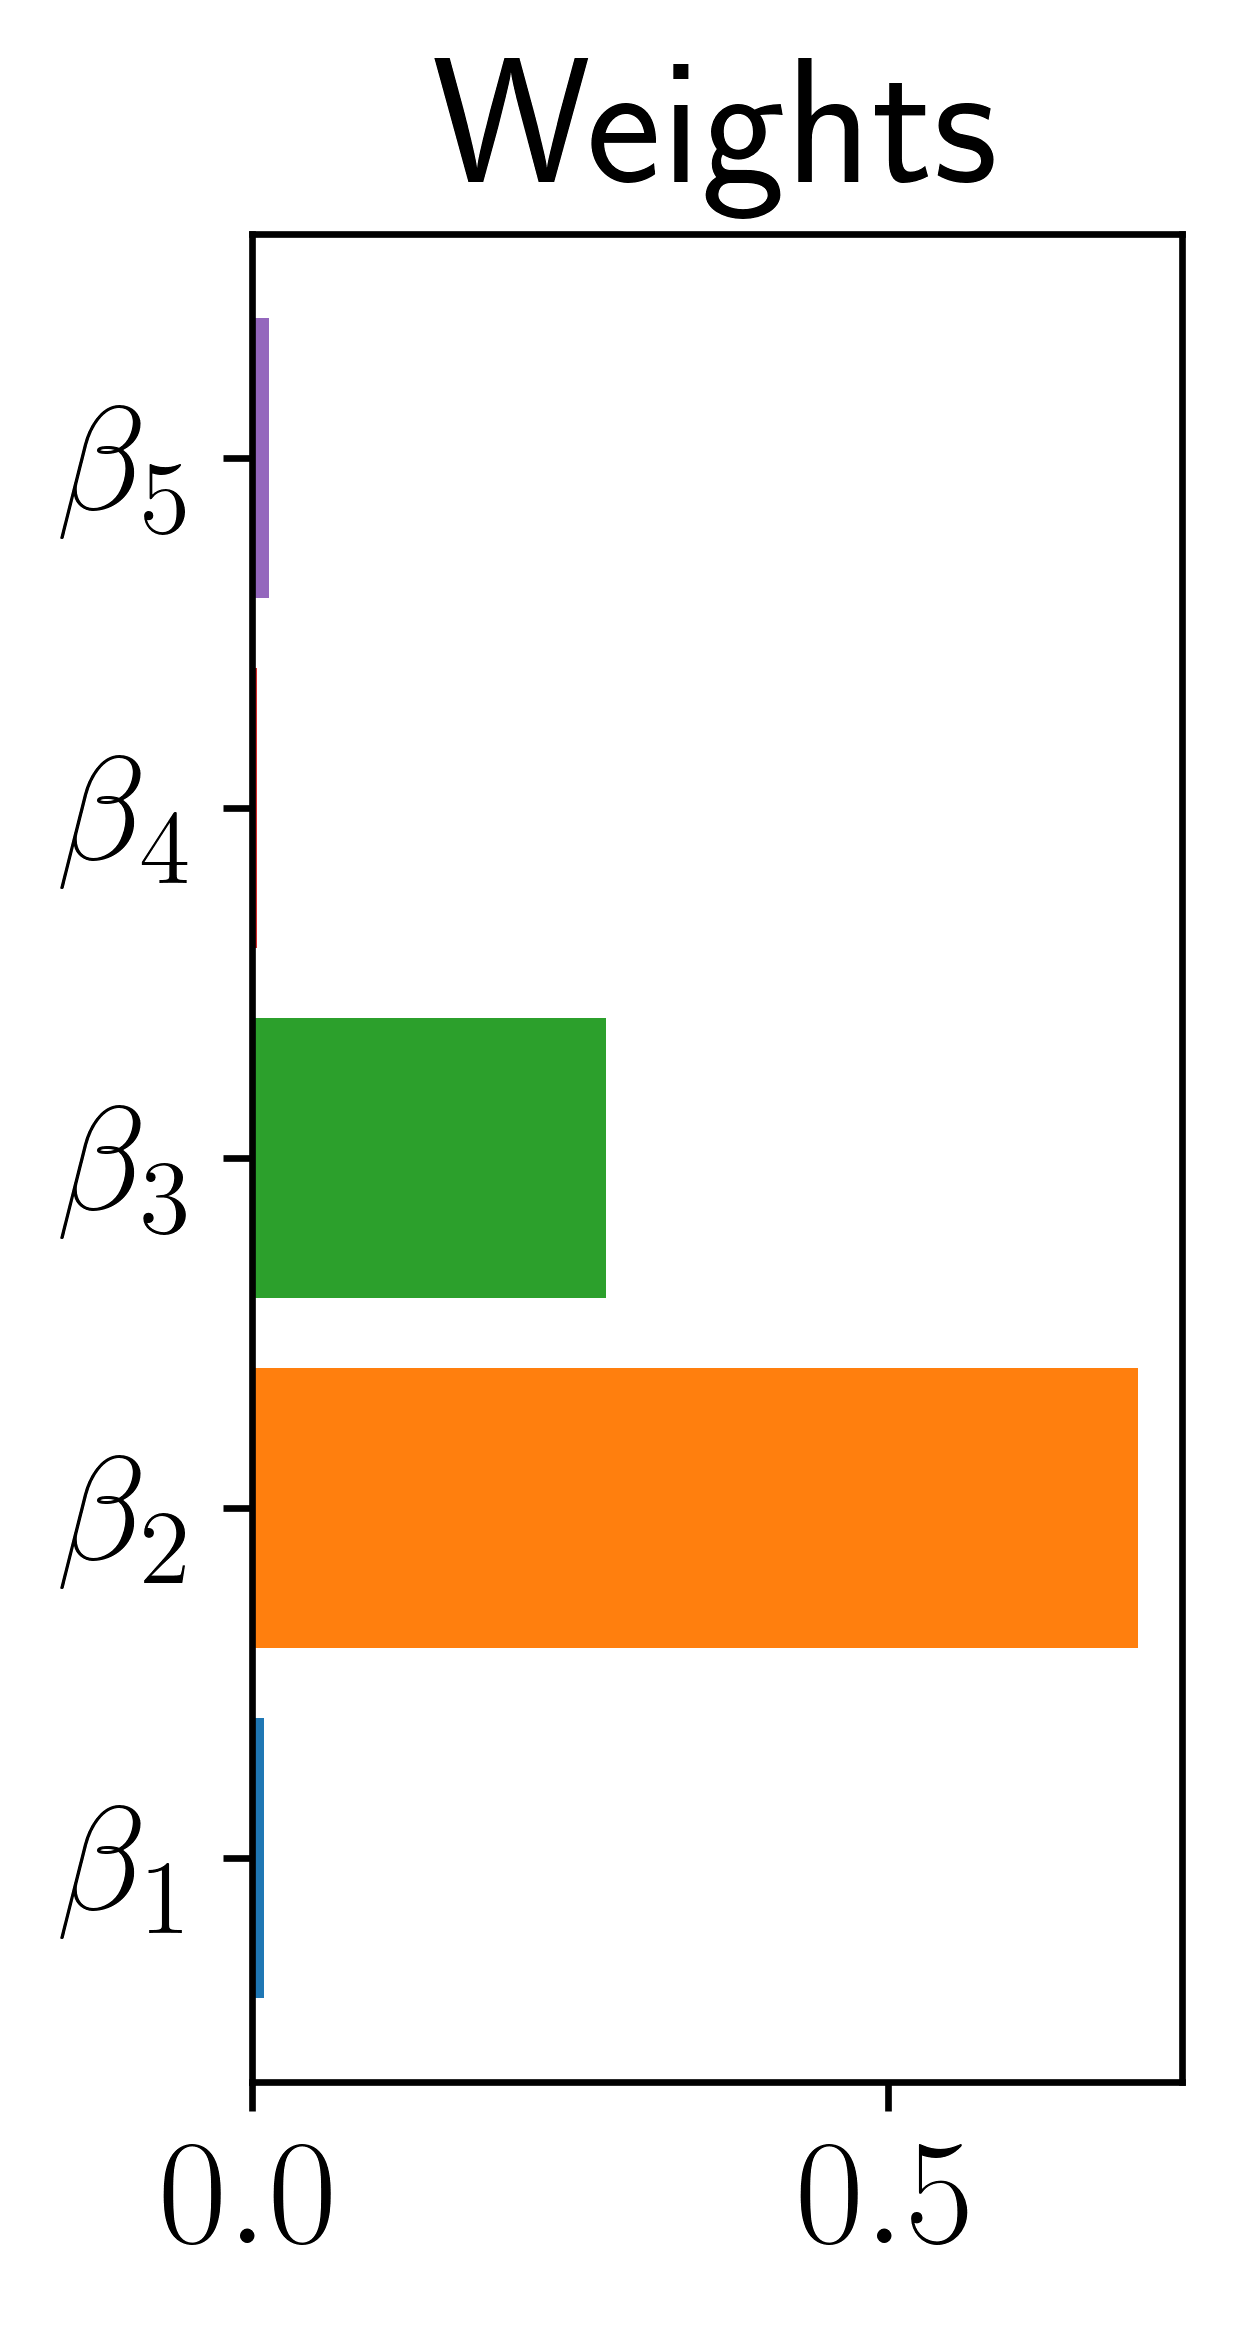

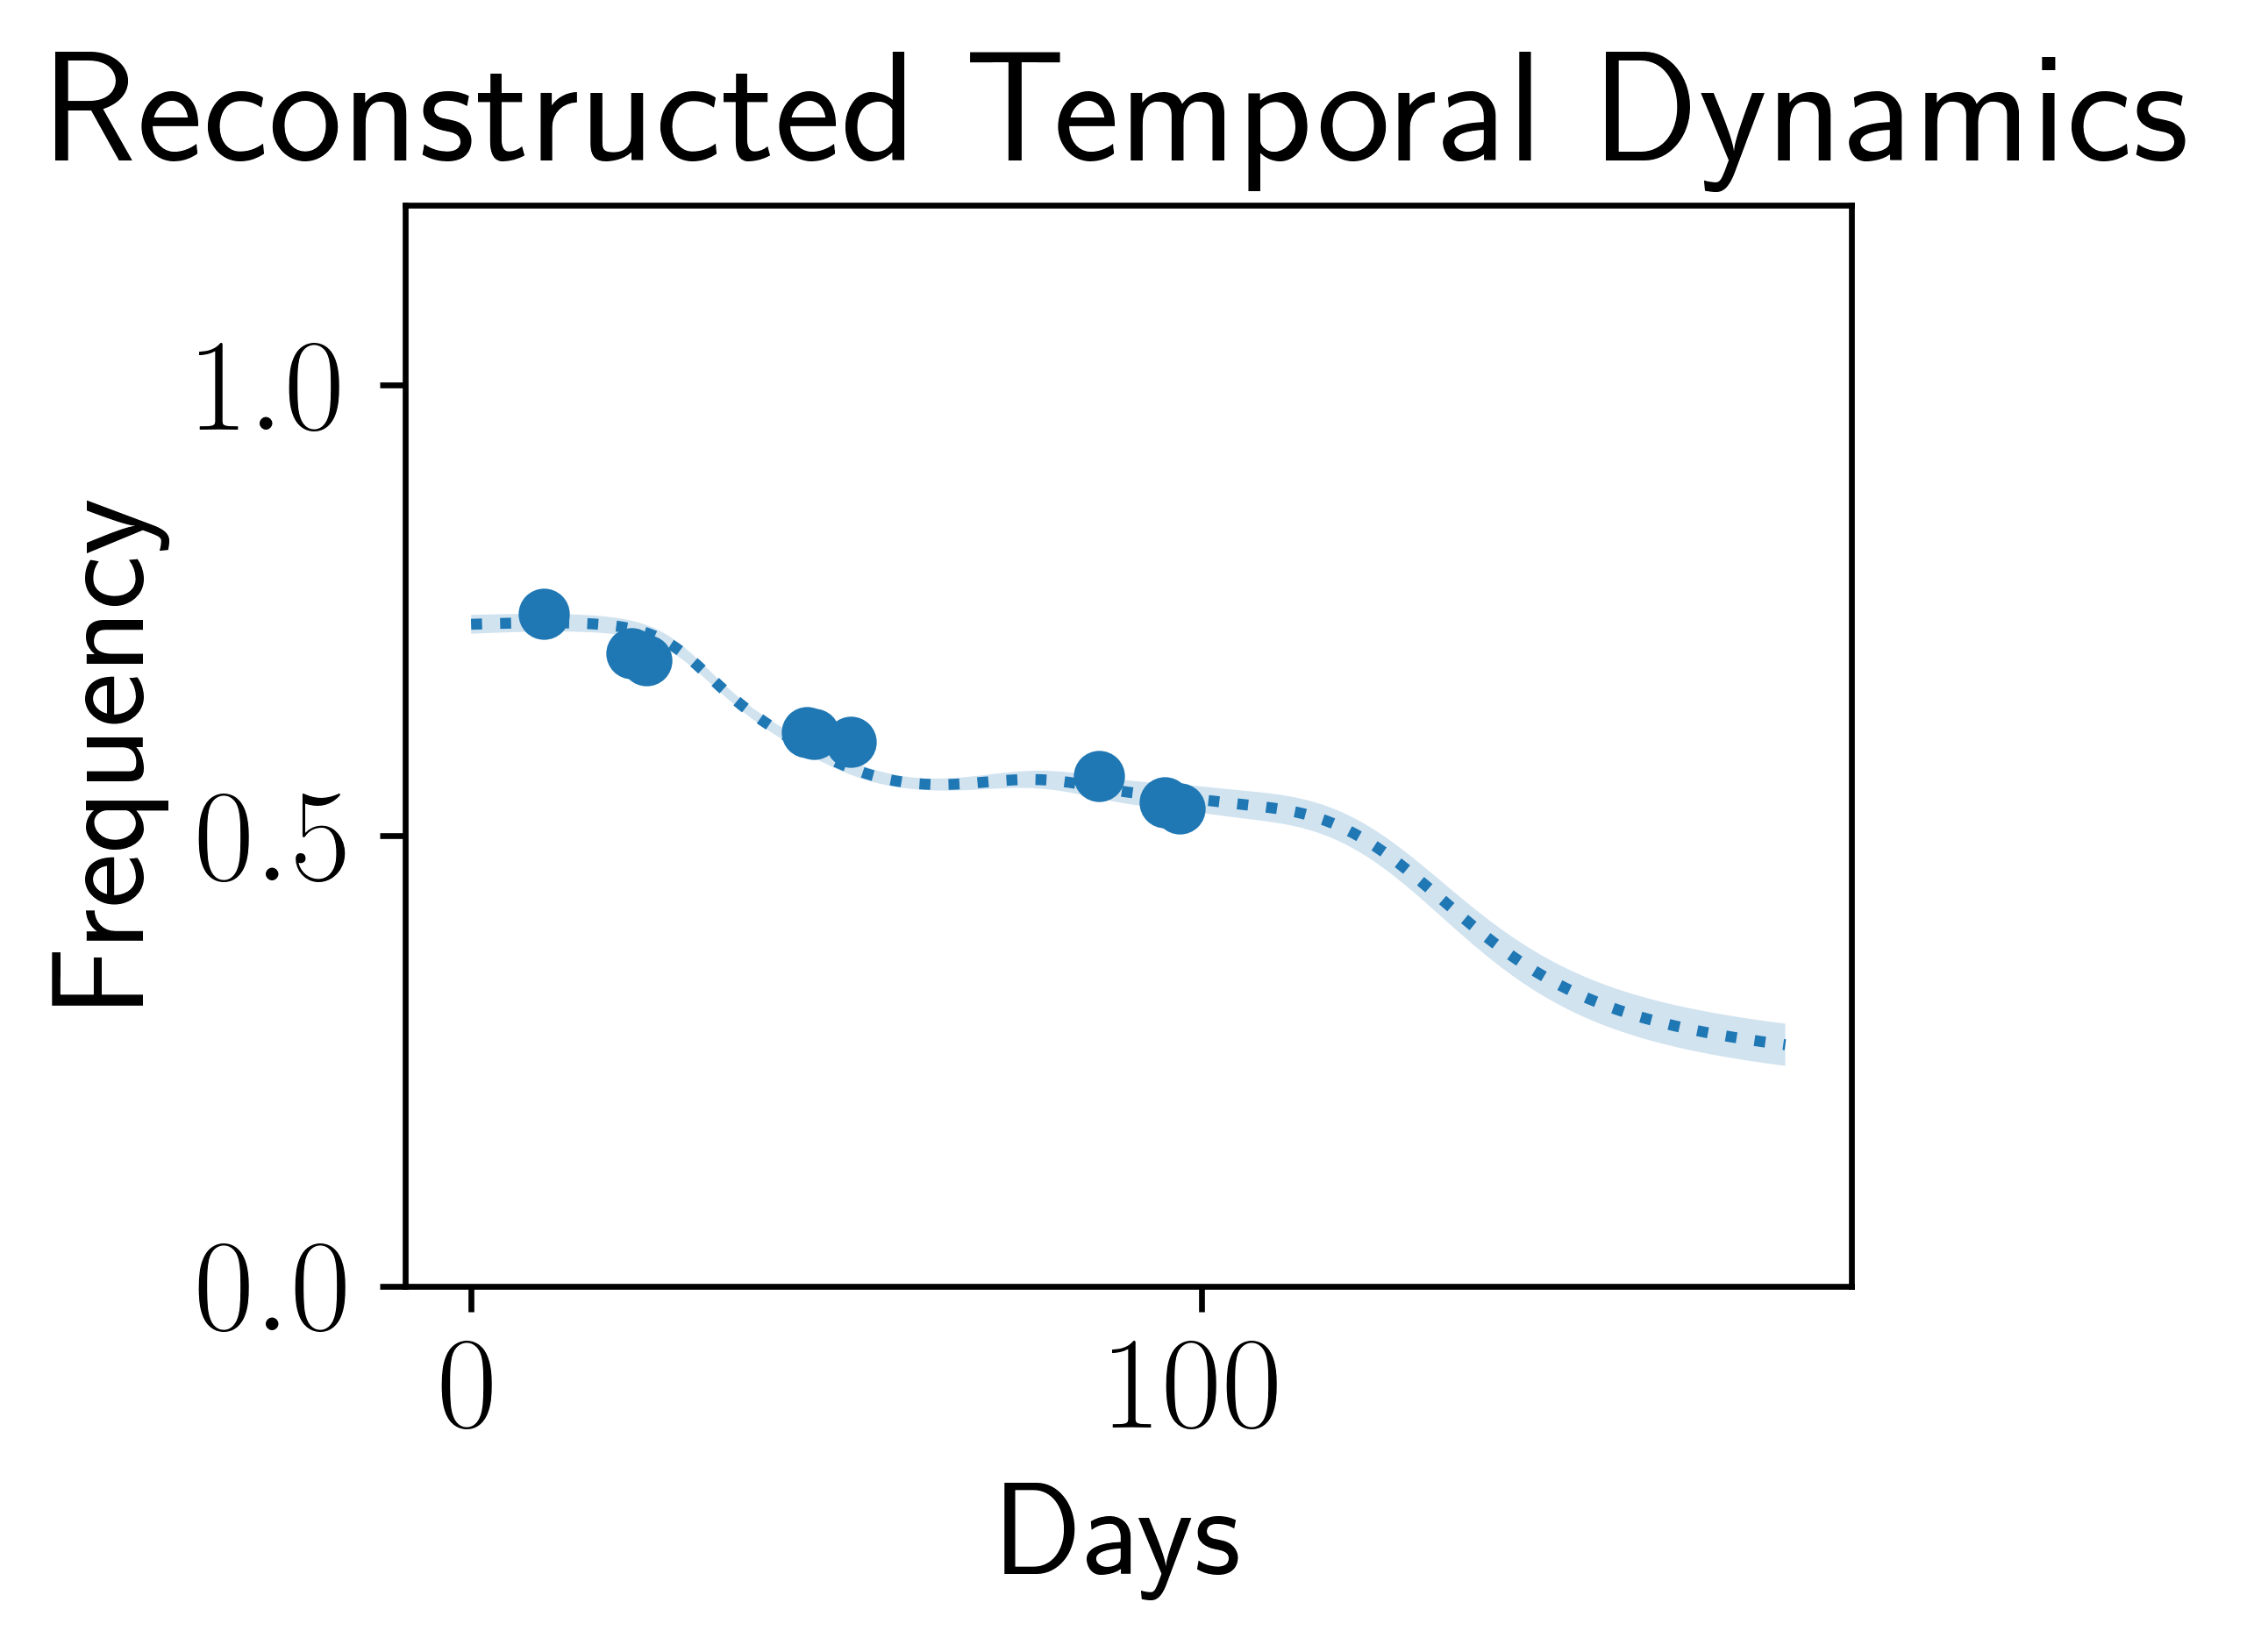

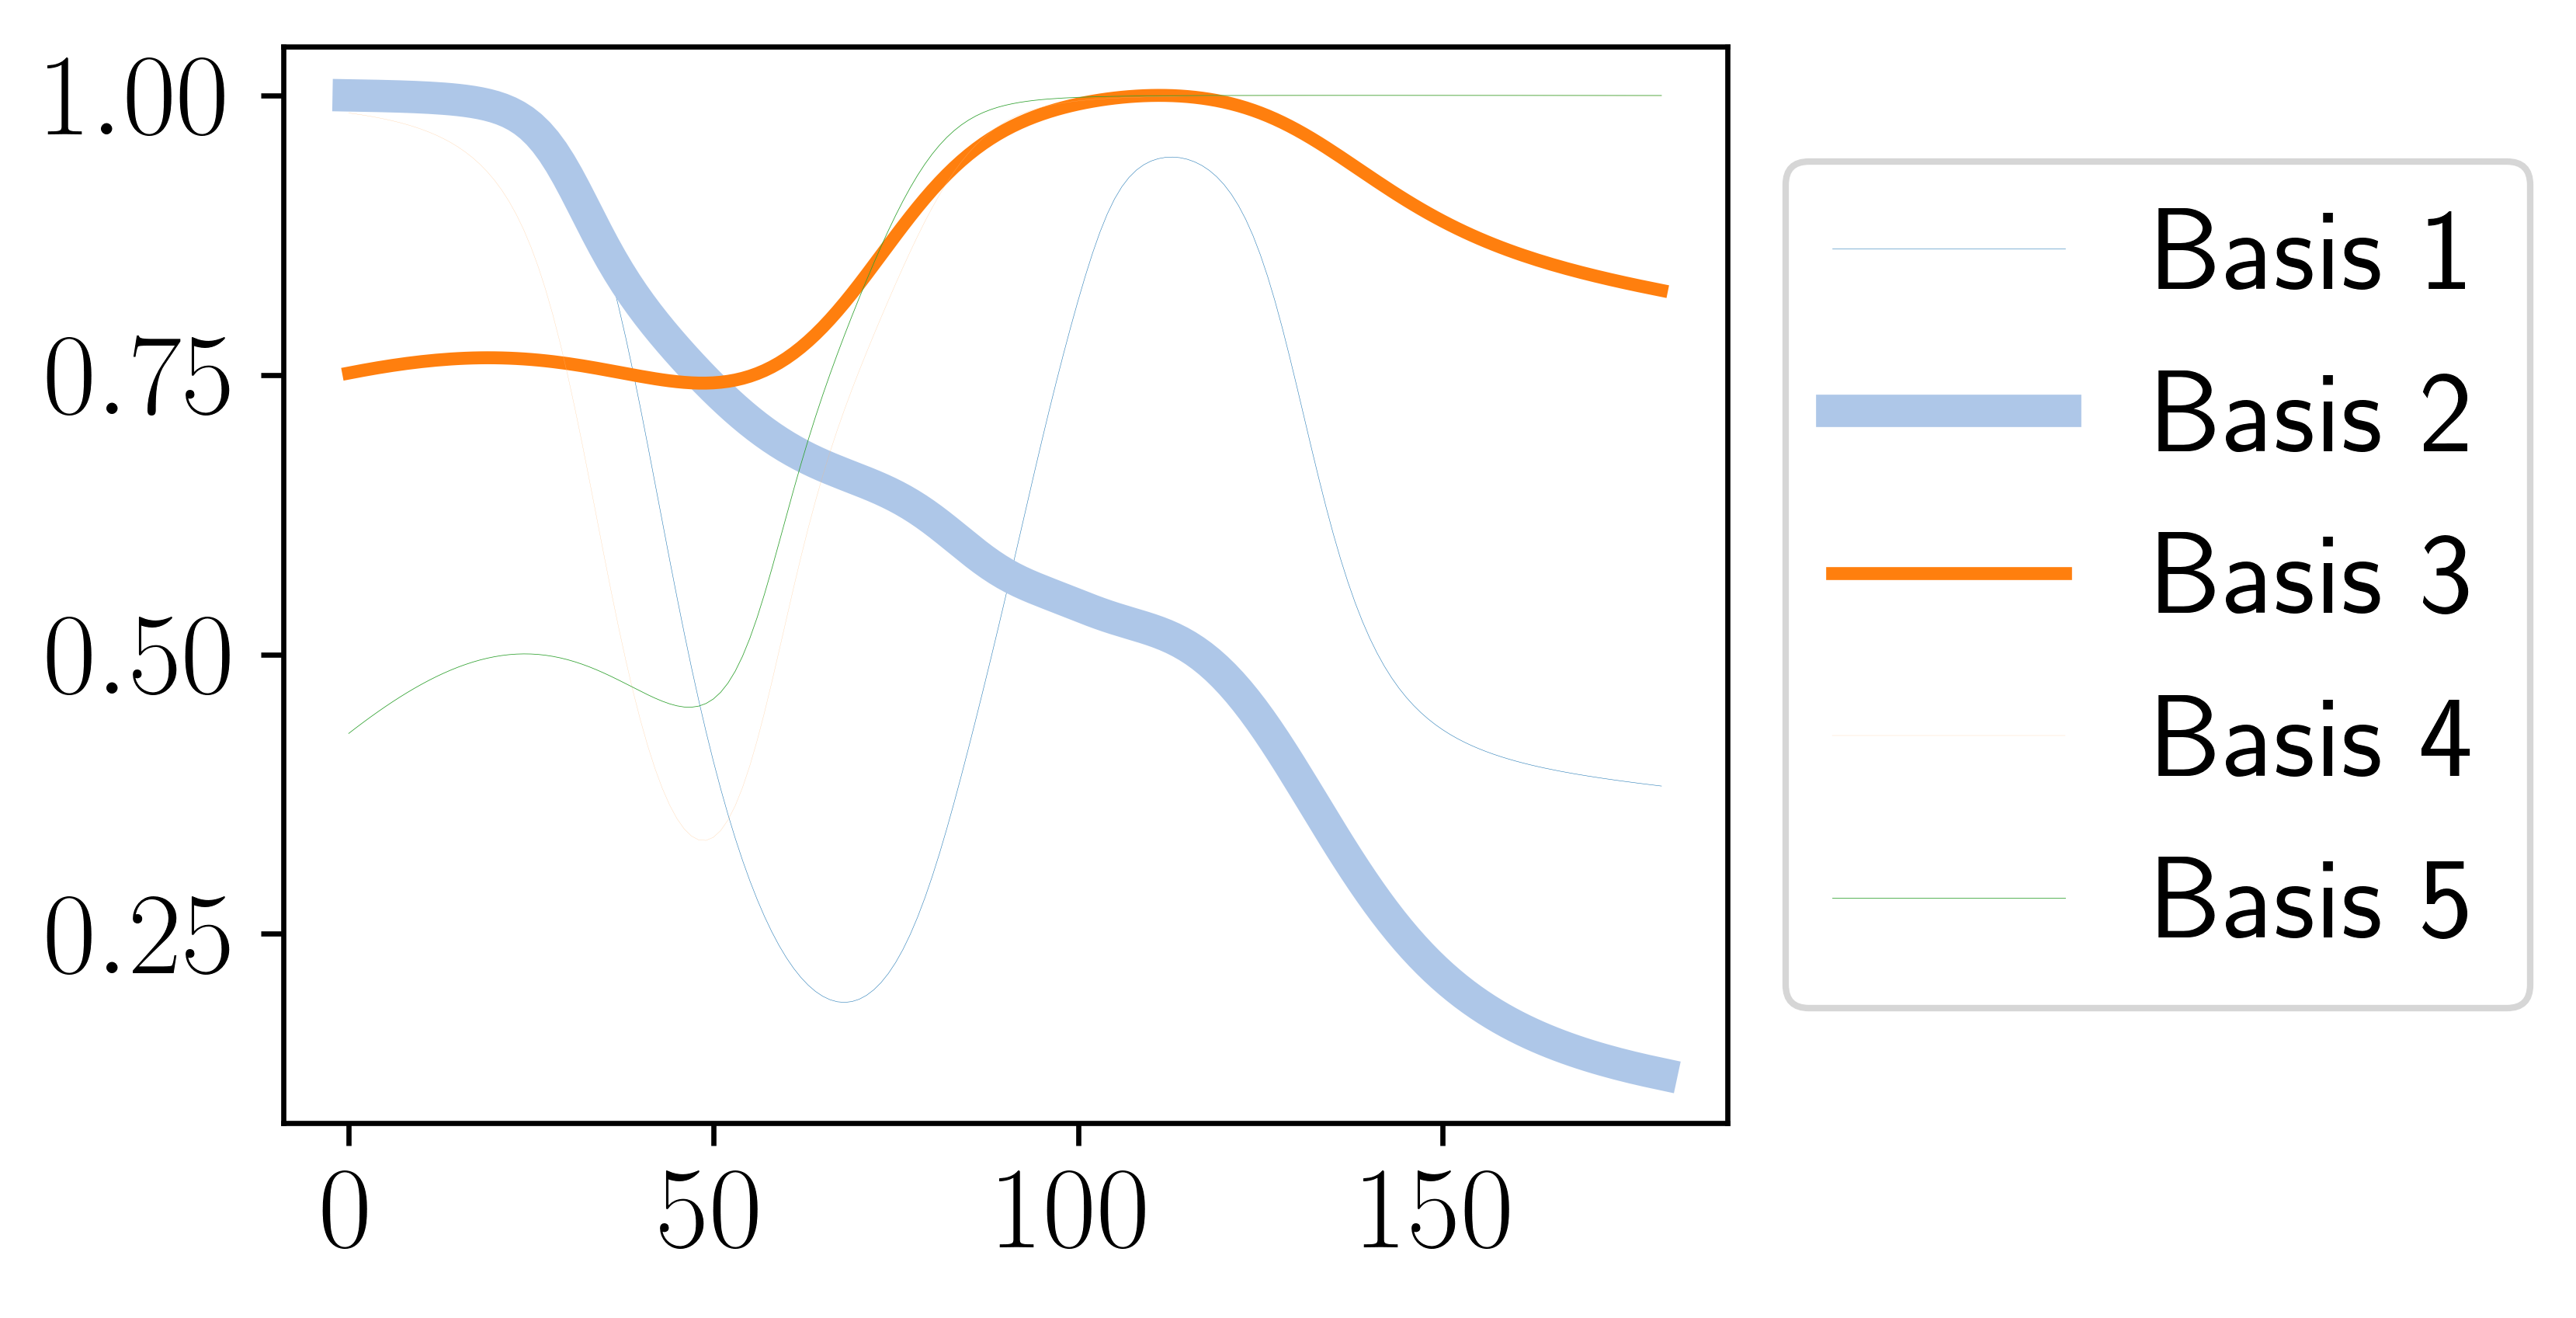

In [14]:
reconstruction = samples_a['_RETURN']['mean']
reconstruction_std = samples_a["_RETURN"]["std"]
reconstruction_q05 = samples_a['_RETURN']['quantile05']
reconstruction_q95 = samples_a['_RETURN']['quantile95']
original = samples_a['obs']['mean']


plt.rcParams.update({'font.size': 18, "text.usetex":True })

#Plot an example clone before fitting
m = 1
palette = sns.color_palette(n_colors = 1)[0]
idx = 0
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
idx = np.random.randint(0,len(clone_patterns_padded_allo_train))
ax.scatter(np.arange(0,181), clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette)
ax.set_xlabel("Days")
ax.set_ylabel("Frequency")
ax.set_ylim([0,1.2])
ax.set_title("Time Series TCR Data")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["example clone"])
plt.ylim([-0.5,10])
plt.savefig("../FigureOutput/generated_Output/Figure2/example_sim_sample.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/example_sim_sample.pdf", dpi = 600, bbox_inches='tight')
plt.show()

sample_beta = samples_a["beta"]["mean"].squeeze()[idx,:]

#Plot the basis
fig, ax = plt.subplots(1,1, figsize = (6,4), dpi = 600)
for i in range(basis_a.shape[-1]):
    ax.plot(basis_a[:,i], linewidth = 4, color = sns.color_palette("tab10",n_colors=n_basis)[i])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["Basis {}".format(x) for x in range(1,n_basis+1)])
    
ax.set_title("Representative Patterns")
ax.set_xlabel("Days")

plt.savefig("../FigureOutput/generated_Output/Figure2/example_basis.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/example_basis.pdf", dpi = 600, bbox_inches='tight')
plt.show()

#Plot the weights
fig, ax = plt.subplots(1,1, figsize = (2,4), dpi = 600)
ax.barh(y = np.arange(1,n_basis + 1), width = sample_beta, color = sns.color_palette("tab10",n_colors=n_basis))
ax.set_yticks(np.arange(1,n_basis+1))
ax.set_yticklabels(["$\\beta_{"+str(x)+"}$" for x in range(1,n_basis+1)])
ax.set_title("Weights")


plt.savefig("../FigureOutput/generated_Output/Figure2/example_weights.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/example_weights.pdf", dpi = 600, bbox_inches='tight')
plt.show()

#Plot the reconstruction
fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
fig.tight_layout()
ax.scatter(np.arange(0,181), clone_patterns_padded_allo_train[idx,:].detach().numpy(), color = palette)
ax.plot(np.arange(0,181), reconstruction.numpy()[idx,:], ls = ':', color = palette)
ax.fill_between(np.arange(0,181), y1 = reconstruction.numpy()[idx,:] - reconstruction_std.numpy()[idx,:], y2 = reconstruction.numpy()[idx,:] + reconstruction_std.numpy()[idx,:], alpha = 0.2)
ax.set_xlabel("Days")
ax.set_ylabel("Frequency")
ax.set_title("Reconstructed Temporal Dynamics")
ax.set_ylim([0,1.2])
plt.savefig("../FigureOutput/generated_Output/Figure2/example_reconstructed.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/example_reconstructed.pdf", dpi = 600, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1,1, figsize = (4,3), dpi = 600)
line_width = samples_a['beta']['mean'].squeeze()[idx,:]
line_width = line_width/line_width.max() * 5

for i in range(basis_a.shape[-1]):
    ax.plot(basis_a[:,i], linewidth = line_width[i], color = sns.color_palette("tab20",n_colors=n_basis)[i])
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), labels = ["Basis {}".format(x) for x in range(1,n_basis+1)])

plt.show()

## Evaluate the Model Fit

0.8629438281059265
(2, 41628)


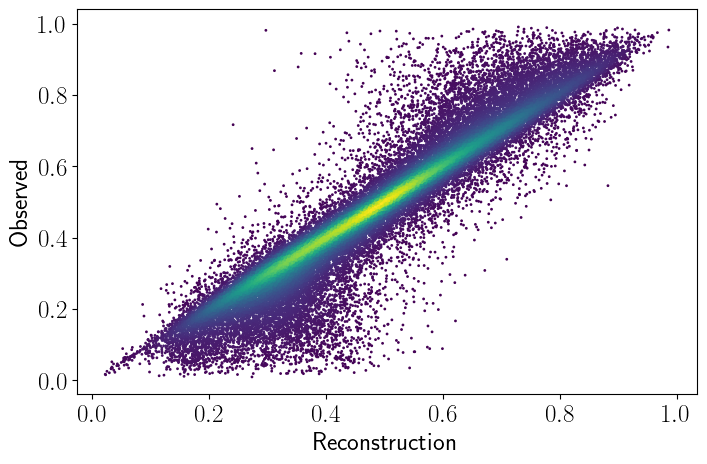

0.818379282951355


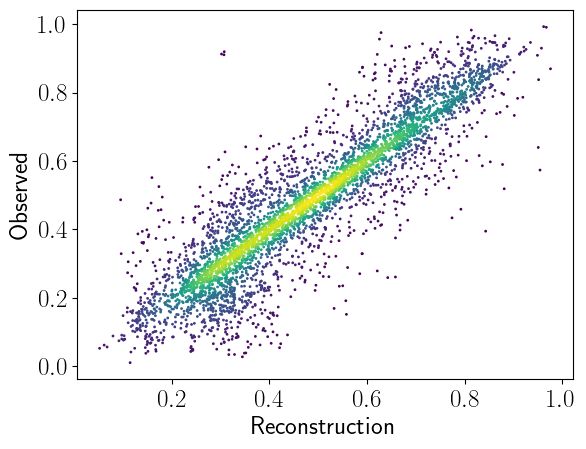

In [ ]:
reconstruction_val = samples["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()
reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

train_R2 = r2_score(clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())].flatten(),reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())].flatten())
print(train_R2)

d = np.vstack([reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())]])
kernel = gaussian_kde(d)
values = kernel(d)
print(d.shape)
fig, ax = plt.subplots(1,1, figsize = (8,5))

m = 5
ax.scatter(reconstruction.numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], clone_patterns_padded_allo_train.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_train.detach())], s = 1,
            c = values)

ax.set_ylabel("Observed")
ax.set_xlabel("Reconstruction")

plt.savefig("../FigureOutput/generated_Output/Figure2/R2onTrain.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/R2onTrain.pdf", dpi = 600, bbox_inches='tight')

plt.show()


val_R2 = r2_score(clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())].flatten(),reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())].flatten())
print(val_R2)

d = np.vstack([reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())]])
kernel = gaussian_kde(d)
values = kernel(d)

m = 5
plt.scatter(reconstruction_val.numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], clone_patterns_padded_allo_val.detach().numpy()[~torch.isnan(clone_patterns_padded_allo_val.detach())], s = 1,
            c = values)

plt.ylabel("Observed")
plt.xlabel("Reconstruction")

plt.savefig("../FigureOutput/generated_Output/Figure2/R2onVal.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/Figure2/R2onVal.pdf", dpi = 600, bbox_inches='tight')

plt.show()

0.4079495668411255


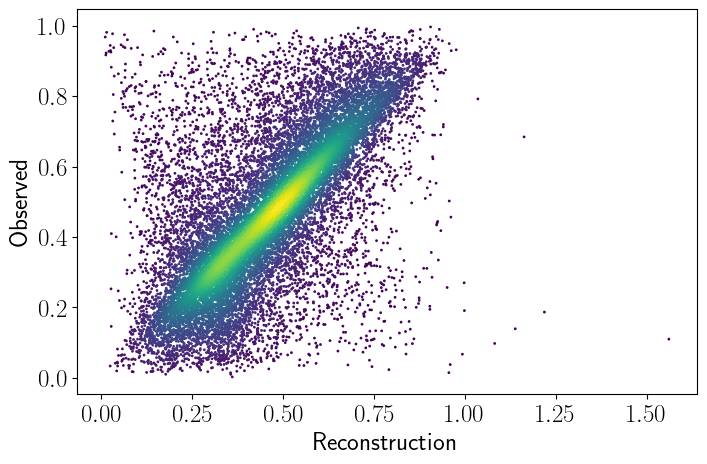

In [16]:
#Now evaluate on all data
reconstruction_val = samples["beta_val"]["mean"].squeeze() @ basis_a.T * model_val.gene_scales.detach().numpy()
reconstruction = samples_a['_RETURN']['mean']
original = samples_a['obs']['mean']

train_R2 = r2_score(gt_train.numpy().flatten(),reconstruction.numpy().flatten())
print(train_R2)

rand_idx = np.random.randint(0, len(reconstruction.numpy().flatten()), 20000)

d = np.vstack([reconstruction.numpy().flatten()[rand_idx], gt_train.numpy().flatten()[rand_idx]])
kernel = gaussian_kde(d)
values = kernel(d)

fig, ax = plt.subplots(1,1, figsize = (8,5))

# m = 5
ax.scatter(reconstruction.numpy().flatten()[rand_idx], gt_train.numpy().flatten()[rand_idx], s = 1,c = values)

ax.set_ylabel("Observed")
ax.set_xlabel("Reconstruction")

plt.savefig("../FigureOutput/generated_Output/R2OnAll.png", dpi = 600, bbox_inches='tight')
plt.savefig("../FigureOutput/generated_Output/R2OnAll.pdf", dpi = 600, bbox_inches='tight')

plt.show()

In [20]:
clone_scales_a = clone_scales_a.detach().numpy()
clone_scales_a = np.expand_dims(clone_scales_a, axis = 0)

beta_a = samples_a['beta']['mean'].squeeze()
beta_a = beta_a[:len(train_a_idx)]
beta_and_scale_a = np.concatenate([beta_a], axis = 1)
beta_and_scale_df_a = pd.DataFrame(beta_and_scale_a)
col_names = np.concatenate([np.linspace(1, n_basis, n_basis, dtype = int).astype(str), ["clone_scales"]])

beta_a_val = samples['beta_val']['mean'].squeeze()
beta_a_val = beta_a_val[:len(val_a_idx)]
beta_and_scale_a_val = np.concatenate([beta_a_val], axis = 1)
beta_and_scale_df_a_val = pd.DataFrame(beta_and_scale_a_val)
col_names = np.concatenate([np.linspace(1, n_basis, n_basis, dtype = int).astype(str), ["clone_scales"]])

adjacency = kneighbors_graph(np.concatenate([beta_and_scale_df_a.values,beta_and_scale_df_a_val.values]), 
                             n_neighbors = 300, 
                             mode = "distance" , 
                             metric = "euclidean")


louvain = Louvain(.17)
labels_allo = louvain.fit_predict(adjacency)
labels_allo_train = labels_allo[:beta_and_scale_a.shape[0]]
labels_allo_val = labels_allo[beta_and_scale_a.shape[0]:]
print(np.unique(labels_allo))

new_categorical = pd.DataFrame(random_weights)
new_categorical.columns = new_categorical.columns + 1


new_categorical["Grade"] = labels_allo

n_No = np.round(12*np.sum(labels_allo == 0)/len(labels_allo))
n_Mild = np.round(12*np.sum(labels_allo == 1)/len(labels_allo))
n_Severe = np.round(12*np.sum(labels_allo == 2)/len(labels_allo))

start = 1

for idx, n in enumerate(np.cumsum([n_No, n_Mild, n_Severe])):
    new_categorical.loc[labels_allo == idx, "PatientID"] = np.random.randint(start, start+n, np.sum(labels_allo == idx))
    start += n


new_categorical

[0 1 2]


,1,2,3,4,5,Grade,PatientID
0,0.235250,0.232354,0.152219,0.347462,0.032715,0,3.0
1,0.190834,0.000060,0.549709,0.056092,0.203304,0,2.0
2,0.334069,0.000807,0.440538,0.004629,0.219957,1,11.0
3,0.023456,0.025437,0.643064,0.298394,0.009649,1,12.0
4,0.034073,0.512149,0.075853,0.363157,0.014768,0,5.0
...,...,...,...,...,...,...,...
9995,0.064892,0.006619,0.395494,0.024639,0.508356,0,2.0
9996,0.274194,0.066353,0.458024,0.167073,0.034356,1,13.0
9997,0.025551,0.217346,0.112036,0.529731,0.115336,2,19.0
9998,0.350349,0.077857,0.004419,0.227830,0.339544,1,6.0


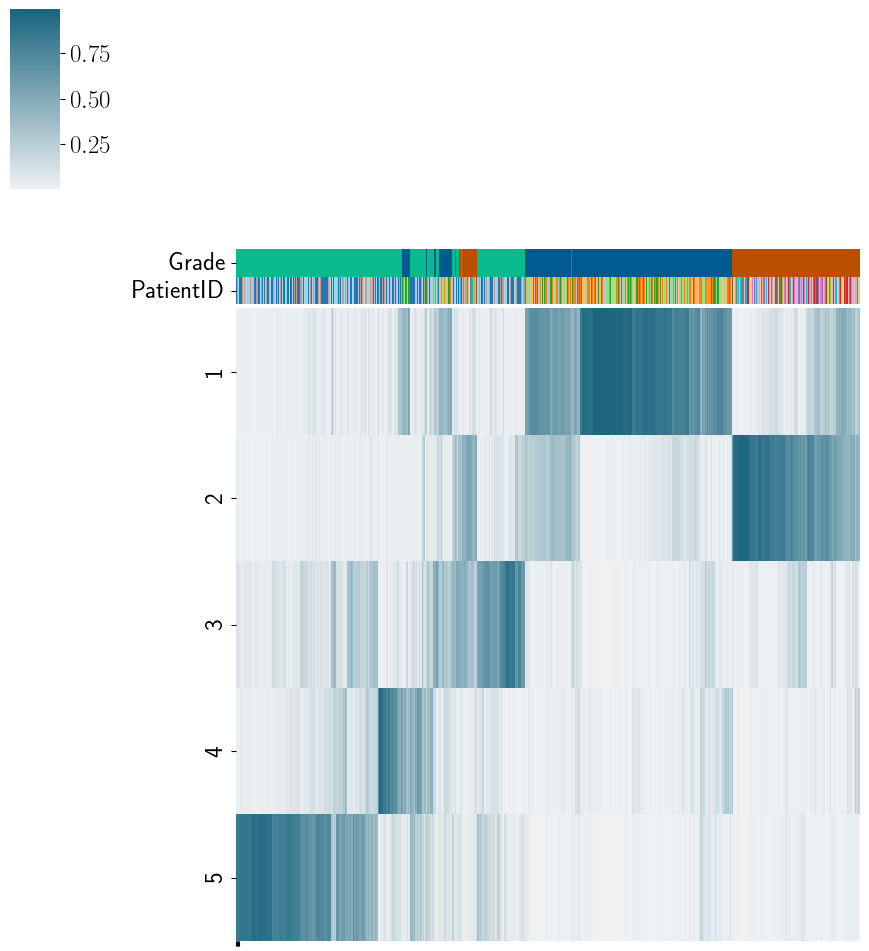

In [21]:
row_categories = ["Grade", "PatientID"]

beta_and_scale_df_a.columns += 1

legend_positions = np.array([[0.5,5.0, .75,.75],
          [1.6,0.32, .75,.75],
          [0.5,4.0, .75,.75],
          [1.7,1.0, .75,.75]])
        #   [0.5,1.0, .75,.75]])

legend_colors = [
    sns.color_palette(["#09BB8C", "#005A8F", "#B85000"]),
    sns.color_palette("tab20", len(np.unique(new_categorical["PatientID"]))),

]

offset = [-7, -3, -2, -1, -1.5]

legend_sizes = [
    (1,1),
    (1,7),
    (1,5),
    (1,1),
    (1,2),
]

sample_idx = np.random.choice(len(beta_and_scale_df_a), 1000, replace = False).astype(int)
beta_and_scale_df_a_ds = beta_and_scale_df_a.loc[sample_idx,:].reset_index(drop = True)
new_categorical_ds = new_categorical.loc[sample_idx, :]

ax = clustermap(beta_and_scale_df_a_ds, new_categorical_ds, row_categories, offset, legend_positions, legend_colors, legend_sizes, "GVHD", display_cbar = False)

ax.savefig("../FigureOutput/generated_Output/Figure2/example_clustermap.png", dpi = 600, bbox_inches='tight')
ax.savefig("../FigureOutput/generated_Output/Figure2/example_clustermap.pdf", dpi = 600, bbox_inches='tight')

